In [1]:
#This notebook exports a csv that models bp cuff deflation for someone with hypotension
#Author: Joshua Van Tuyl
#VitalCentric Project

#Imports
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import csv
import statistics

#Importing healthy blood pressure data
b = pd.read_csv("Hypotension_JVT_02182026.csv")
#Saving csv columns as data lists
hypo_data = b.to_dict(orient="list")
#Saving each column as a discrete list
time = hypo_data["0"]
hypo_bp = hypo_data["80"]
#Healthy BP data called h(t)

In [2]:
#Create Gaussian Function g(t)
#Takes in inputs of time and outputs values
#A is a scaling constant
def gauss(t, mu, sigma, A):
    g = A * np.exp(-1 * ((t - mu)**2) / (2 * sigma**2))
    return g

In [3]:
#Exponential decay
y0 = 180
k = 0.085

def decay(t, y0, k):
    c = y0 * np.exp(-k*t)
    return c

In [4]:
#saving linear decay data, need deflation pressure > 0 

t_decay = np.linspace(0, 22, 1208)
p = decay(t_decay, y0, k)


In [5]:
#Extracting when local maxima (systolic pressure) occurs
test = find_peaks(hypo_bp)
peaks_index = test[0].tolist()
#peaks_index is a list of indices that correspond to pressure values in healthy_bp
systole = []
t_maxima = []
for x in range(0, len(peaks_index)):
    systole.append(hypo_bp[peaks_index[x]])
    t_maxima.append(time[peaks_index[x]])

In [6]:
#extracting when local minima occurs
invert = []
for x in range(0, len(hypo_bp)):
    invert.append(-1 * hypo_bp[x])
mins = find_peaks(invert)
vall_index = mins[0].tolist()
#vall_index is a list of indices that ciorrespond to local pressure minima in healthy_bp
diastole = []
t_minima = []
for x in range(0, len(vall_index)):
    diastole.append(hypo_bp[vall_index[x]])
    t_minima.append(time[vall_index[x]])

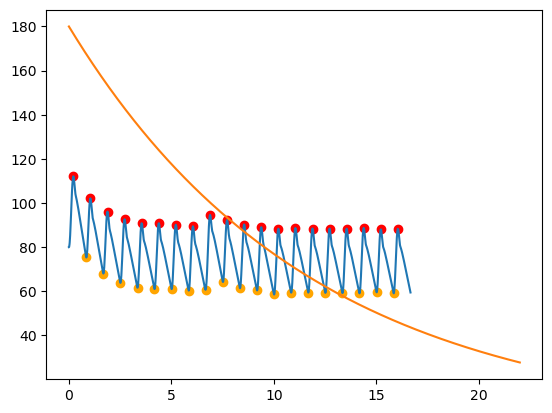

In [7]:
plt.scatter(t_maxima, systole, color="red")
plt.scatter(t_minima, diastole, color="orange")
plt.plot(time, hypo_bp)
plt.plot(t_decay, p)
#NEED TO EXTEND BP DATA TO 20 seconds